In [1]:
# This notebook contains code for time series forecasting AutoArima and ForecasterAutoreg (ML-based forecasting)
# Environmental data from https://aqicn.org/historical/#city:ireland/finglas--dublin-11
# Used Python 8.
# 
# Relevant links:
# https://medium.com/@mouse3mic3/a-practical-guide-on-scikit-learn-for-time-series-forecasting-bbd15b611a5d
# https://skforecast.org/0.7.0/user_guides/quick-start-skforecast
# https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html
# https://matplotlib.org/stable/gallery/text_labels_and_annotations/date.html

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor

from pandas import read_csv, DataFrame, to_datetime, to_numeric
from pmdarima import AutoARIMA, auto_arima
from skforecast.recursive import ForecasterRecursive
from datetime import timedelta

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [30]:
df = read_csv('finglas,-dublin 11-air-quality.csv')    # load some timeseries data
df.columns = df.columns.str.strip()     # clean up extra spaces in the column header
df.head()

,date,pm25,pm10
0,2024/12/2,14,6
1,2024/12/3,17,13
2,2024/12/4,38,
3,2024/11/2,51,14
4,2024/11/3,52,12


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1386 entries, 2021-02-18 to 2024-12-04
Freq: D
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pm25    1386 non-null   float64
 1   pm10    1386 non-null   float64
 2   month   1386 non-null   int32  
dtypes: float64(2), int32(1)
memory usage: 70.2 KB


In [31]:
df['date'] = to_datetime(df['date'], yearfirst=True)
df.set_index('date', inplace=True)
df = df.asfreq('d')         # make sure it is daily data (to mark gaps between days)
df.head()

,pm25,pm10
date,,
2021-02-18,,8
2021-02-19,19,6
2021-02-20,15,11
2021-02-21,33,10
2021-02-22,25,11


In [33]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1386 entries, 2021-02-18 to 2024-12-04
Freq: D
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   pm25    1364 non-null   object
 1   pm10    1364 non-null   object
dtypes: object(2)
memory usage: 32.5+ KB


pm25    22
pm10    22
dtype: int64

In [34]:
# Only PM2.5 and PM10? Let's create one more column called "month" (hopefully a good feature!)
df['month'] = df.index.month
df.head()

,pm25,pm10,month
date,,,
2021-02-18,,8,2
2021-02-19,19,6,2
2021-02-20,15,11,2
2021-02-21,33,10,2
2021-02-22,25,11,2


In [35]:
# missing values will now appear as NaN
df = df.apply(to_numeric, errors='coerce')
df.head()

,pm25,pm10,month
date,,,
2021-02-18,NaN,8.0,2
2021-02-19,19.0,6.0,2
2021-02-20,15.0,11.0,2
2021-02-21,33.0,10.0,2
2021-02-22,25.0,11.0,2


In [36]:
# We have lots of missing values.
df.isnull().sum()

pm25     31
pm10     31
month     0
dtype: int64

In [37]:
# impute missing numerical values using linear interpolation
df = df.interpolate()
df.head()

,pm25,pm10,month
date,,,
2021-02-18,NaN,8.0,2
2021-02-19,19.0,6.0,2
2021-02-20,15.0,11.0,2
2021-02-21,33.0,10.0,2
2021-02-22,25.0,11.0,2


In [38]:
df.bfill(inplace=True)          # backward fill that NaN
df.head()

,pm25,pm10,month
date,,,
2021-02-18,19.0,8.0,2
2021-02-19,19.0,6.0,2
2021-02-20,15.0,11.0,2
2021-02-21,33.0,10.0,2
2021-02-22,25.0,11.0,2


In [39]:
# re-count missing values. Looks good.
df.isnull().sum()

pm25     0
pm10     0
month    0
dtype: int64

In [40]:
# Decide a target variable. Let's say we take PM2.5
target = 'pm25'
df[target]

date
2021-02-18    19.0
2021-02-19    19.0
2021-02-20    15.0
2021-02-21    33.0
2021-02-22    25.0
              ... 
2024-11-30    23.0
2024-12-01    17.0
2024-12-02    14.0
2024-12-03    17.0
2024-12-04    38.0
Freq: D, Name: pm25, Length: 1386, dtype: float64

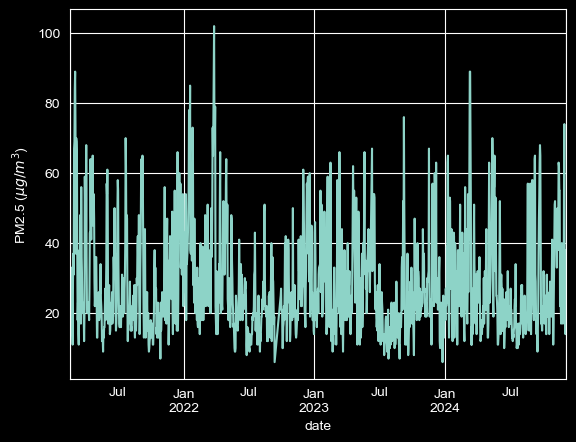

In [41]:
# Let's plot it
df[target].plot(ylabel=r'PM2.5 (${\mu}g/m^3$)')

# yes, it looks horrible...
cutOffDate = '2023-01-01'       # find a good range to fit your timeseries (or all your data, of course!)

In [44]:
print("Data from:", df.index.min())
print("Data to:", df.index.max())
print("Number of days:", len(df))

Data from: 2021-02-18 00:00:00
Data to: 2024-12-04 00:00:00
Number of days: 1386


In [55]:
data2fit = df.loc[cutOffDate:]  # dane do trenowania modeli
arima_cutoff = '2024-01-01'  # ARIMA trenuje na 2023, testuje na 2024
arima_train = data2fit.loc[:arima_cutoff]  # 2023
arima_test = data2fit.loc[arima_cutoff:]    # 2024

arima_model = auto_arima(arima_train[target])

In [56]:
# fit an ARIMA model using one year data

daysAhead = 7                                           # and decide the number of days to predict

arima_model = auto_arima(arima_train[target])           # train  on arima_train (2023)
y_pred = arima_model.predict(daysAhead)                 # prognose 7 days ahead
y_pred


2024-01-02    23.742178
2024-01-03    23.409617
2024-01-04    23.749081
2024-01-05    24.052917
2024-01-06    24.324864
2024-01-07    24.568269
2024-01-08    24.786129
Freq: D, dtype: float64

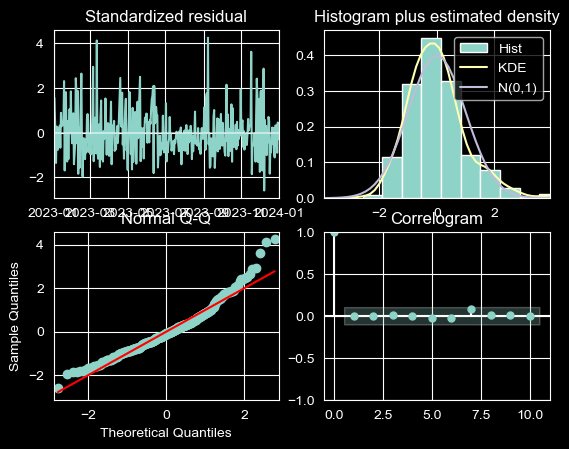

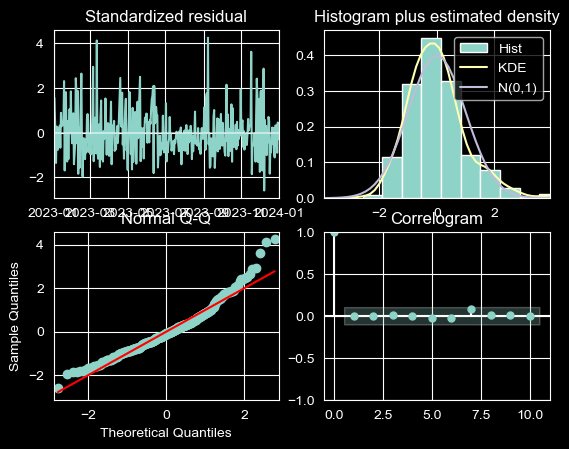

In [57]:
# introspect the model
arima_model.plot_diagnostics()

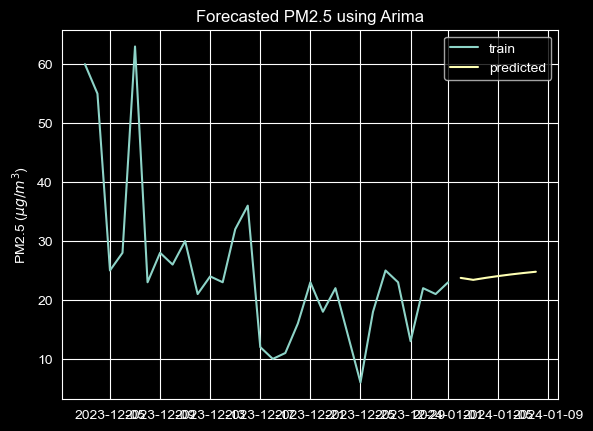

In [58]:
# Plot last month of training data and predicted week of PM2.5
plt.plot(arima_train[-30:][target], label='train')
plt.plot(y_pred, label='predicted')
plt.title('Forecasted PM2.5 using Arima')
plt.ylabel(r'PM2.5 (${\mu}g/m^3$)')
plt.legend()

In [59]:
# Define a ML-based forecaster
gbm_model = ForecasterRecursive(
    regressor = GradientBoostingRegressor(),
    lags = daysAhead
)
# Fit the model using train data
gbm_model.fit(arima_train[target])                                 # only one variable

# Predict next week values of PM2.5
y_pred = gbm_model.predict(daysAhead)
y_pred

C:\Users\tomas\AppData\Local\Temp\ipykernel_33680\1356386770.py:2: FutureWarning: The `regressor` argument is deprecated and will be removed in a future version. Please use `estimator` instead.
  gbm_model = ForecasterRecursive(


2024-01-02    22.497414
2024-01-03    22.706966
2024-01-04    24.298179
2024-01-05    23.109983
2024-01-06    24.787726
2024-01-07    28.022114
2024-01-08    28.249390
Freq: D, Name: pred, dtype: float64

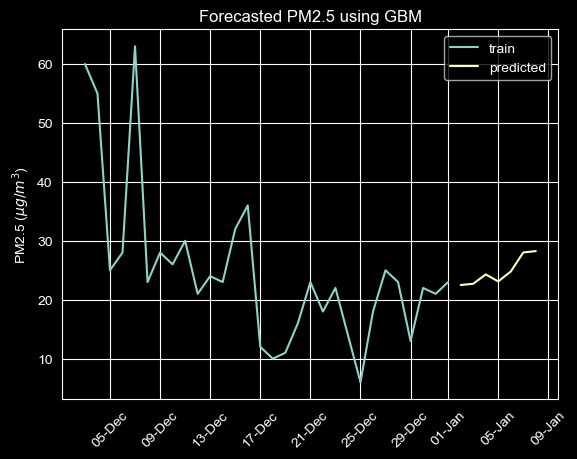

In [60]:
# plot predictions using GBM

# Plot the last week and predicted week (with an example of date formatting)
ax = plt.gca()
ax.plot(arima_train[-30:][target], label='train')
ax.plot(y_pred, label='predicted')           # predict next week
ax.set_title('Forecasted PM2.5 using GBM')
ax.set_ylabel(r'PM2.5 (${\mu}g/m^3$)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax.xaxis.set_tick_params(rotation=45)
ax.legend()

In [63]:
# Prepare exog data using predictions from a given model
def predExogData(model, exog_vars, daysAhead):
    lastDay = arima_train.index[-1]                # zmienione z data2fit
    toPredict = [lastDay + timedelta(days=x+1) for x in range(daysAhead)]
    exogData = DataFrame(0, index=toPredict, columns=exog_vars)

    for e in exog_vars:
        model.fit(arima_train[e])                  # zmienione z data2fit[e]
        exogData[e] = model.predict(daysAhead)
    
    exogData.index = to_datetime(exogData.index)
    exogData = exogData.asfreq('d')
    #
    return exogData

In [64]:
exogData = predExogData(arima_model, ['pm10'], daysAhead)
exogData['month'] = exogData.index.month            # our new feature too
exogData

,pm10,month
2024-01-02,7.299037,1
2024-01-03,8.234502,1
2024-01-04,8.490464,1
2024-01-05,8.695906,1
2024-01-06,8.860799,1
2024-01-07,8.993147,1
2024-01-08,9.099373,1


In [65]:
# AutoArima can use more columns

arima_model.fit(arima_train[target], exog=arima_train[['pm10', 'month']])
y_pred = arima_model.predict(steps=7, exog=exogData)                    # this time using exogenous variables
y_pred

2024-01-02    23.742178
2024-01-03    23.409617
2024-01-04    23.749081
2024-01-05    24.052917
2024-01-06    24.324864
2024-01-07    24.568269
2024-01-08    24.786129
2024-01-09    24.981123
2024-01-10    25.155651
2024-01-11    25.311862
Freq: D, dtype: float64

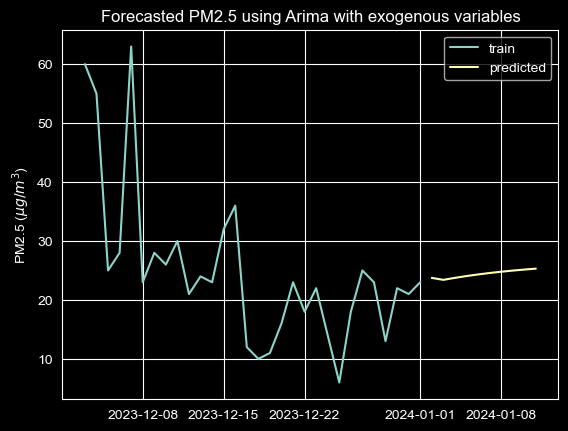

In [66]:
# now, plot last week and the predicted week (model created with multiple columns)
plt.plot(arima_train[-30:][target], label='train')
plt.plot(y_pred, label='predicted')
plt.title('Forecasted PM2.5 using Arima with exogenous variables')
plt.ylabel(r'PM2.5 (${\mu}g/m^3$)')
plt.legend()

In [67]:
# and, finally, ForecasterRecursive using multiple columns
gbm_model.fit(arima_train[target], exog=arima_train[['pm10', 'month']])  # zmienione
y_pred = gbm_model.predict(steps=7, exog=exogData)
y_pred

2024-01-02    22.425194
2024-01-03    19.992260
2024-01-04    23.892672
2024-01-05    23.355614
2024-01-06    22.718751
2024-01-07    24.078565
2024-01-08    27.610623
Freq: D, Name: pred, dtype: float64

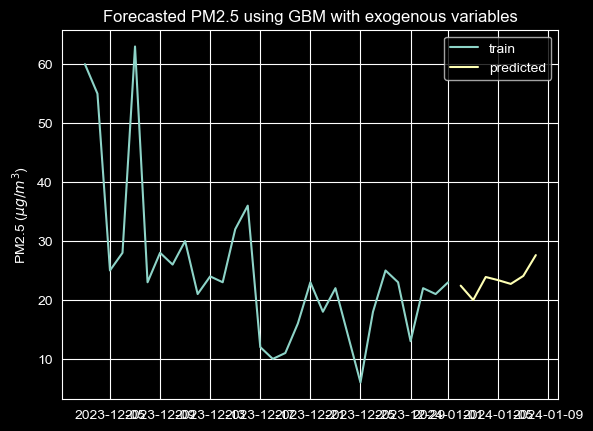

In [68]:
# now, plot last week and the predicted week (model created with multiple columns)
plt.plot(arima_train[-30:][target], label='train')
plt.plot(y_pred, label='predicted')
plt.title('Forecasted PM2.5 using GBM with exogenous variables')
plt.ylabel(r'PM2.5 (${\mu}g/m^3$)')
plt.legend()